In [23]:
import pandas as pd
import numpy as np
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

import webbrowser
from pathlib import Path


## Load data

In [24]:
data_apr = pd.read_csv("../data/raw/uber-raw-data-apr14.csv")
data_aug = pd.read_csv("../data/raw/uber-raw-data-aug14.csv")
data_jul = pd.read_csv("../data/raw/uber-raw-data-jul14.csv")
data_jun = pd.read_csv("../data/raw/uber-raw-data-jun14.csv")
data_may = pd.read_csv("../data/raw/uber-raw-data-may14.csv")
data_sep = pd.read_csv("../data/raw/uber-raw-data-sep14.csv")
uber = pd.concat([data_apr,data_aug, data_jul, data_jun, data_may,data_sep]).reset_index(drop='index')

In [25]:
uber.shape

(4534327, 4)

In [26]:
uber.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


## Feature engineering (weekday)

In [27]:
uber['Pickup_time'] = pd.to_datetime(uber['Date/Time'])
uber['Week_day'] = uber['Pickup_time'].dt.day_name()

uber[['Lat','Lon','Week_day']].head()


,Lat,Lon,Week_day
0,40.7690,-73.9549,Tuesday
1,40.7267,-74.0345,Tuesday
2,40.7316,-73.9873,Tuesday
3,40.7588,-73.9776,Tuesday
4,40.7594,-73.9722,Tuesday


## Sampling

In [28]:
uber_sample = uber.sample(50000, random_state=42).reset_index(drop=True)


## Prepare coordinates

In [29]:
X = uber_sample[['Lat','Lon']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [37]:
week_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

uber_sample["Week_day"] = pd.Categorical(
    uber_sample["Week_day"],
    categories=week_order,
    ordered=True
)

## Elbow Method

In [38]:
wcss = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

px.line(x=range(1,11), y=wcss,
        labels={'x':'K','y':'WCSS'},
        title='Elbow Method')


## Silhouette Score

In [39]:
scores = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

px.bar(x=list(range(2,11)), y=scores,
       labels={'x':'K','y':'Silhouette Score'},
       title='Silhouette Scores')


K selected = 3

The silhouette score was highest for K=2. However, the elbow method suggested that K=3 captures additional structure in the data while still providing a significant reduction in WCSS. Since the project aims to identify actionable hot-zones rather than only maximize a clustering metric, K=3 was selected.

In [40]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
uber_sample['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)


## K-Means Hot Zones Map

In [41]:
file_path = "../data/image/Cluster_KMeans.html"

fig = px.scatter_map(
    uber_sample.sort_values('Week_day'), 
    lat="Lat", 
    lon="Lon", 
    color="Cluster_KMeans",
    animation_frame = 'Week_day',
    zoom=9,
    height=700)

fig.write_html(file_path)

webbrowser.open(f"file://{Path(file_path).resolve()}")


True

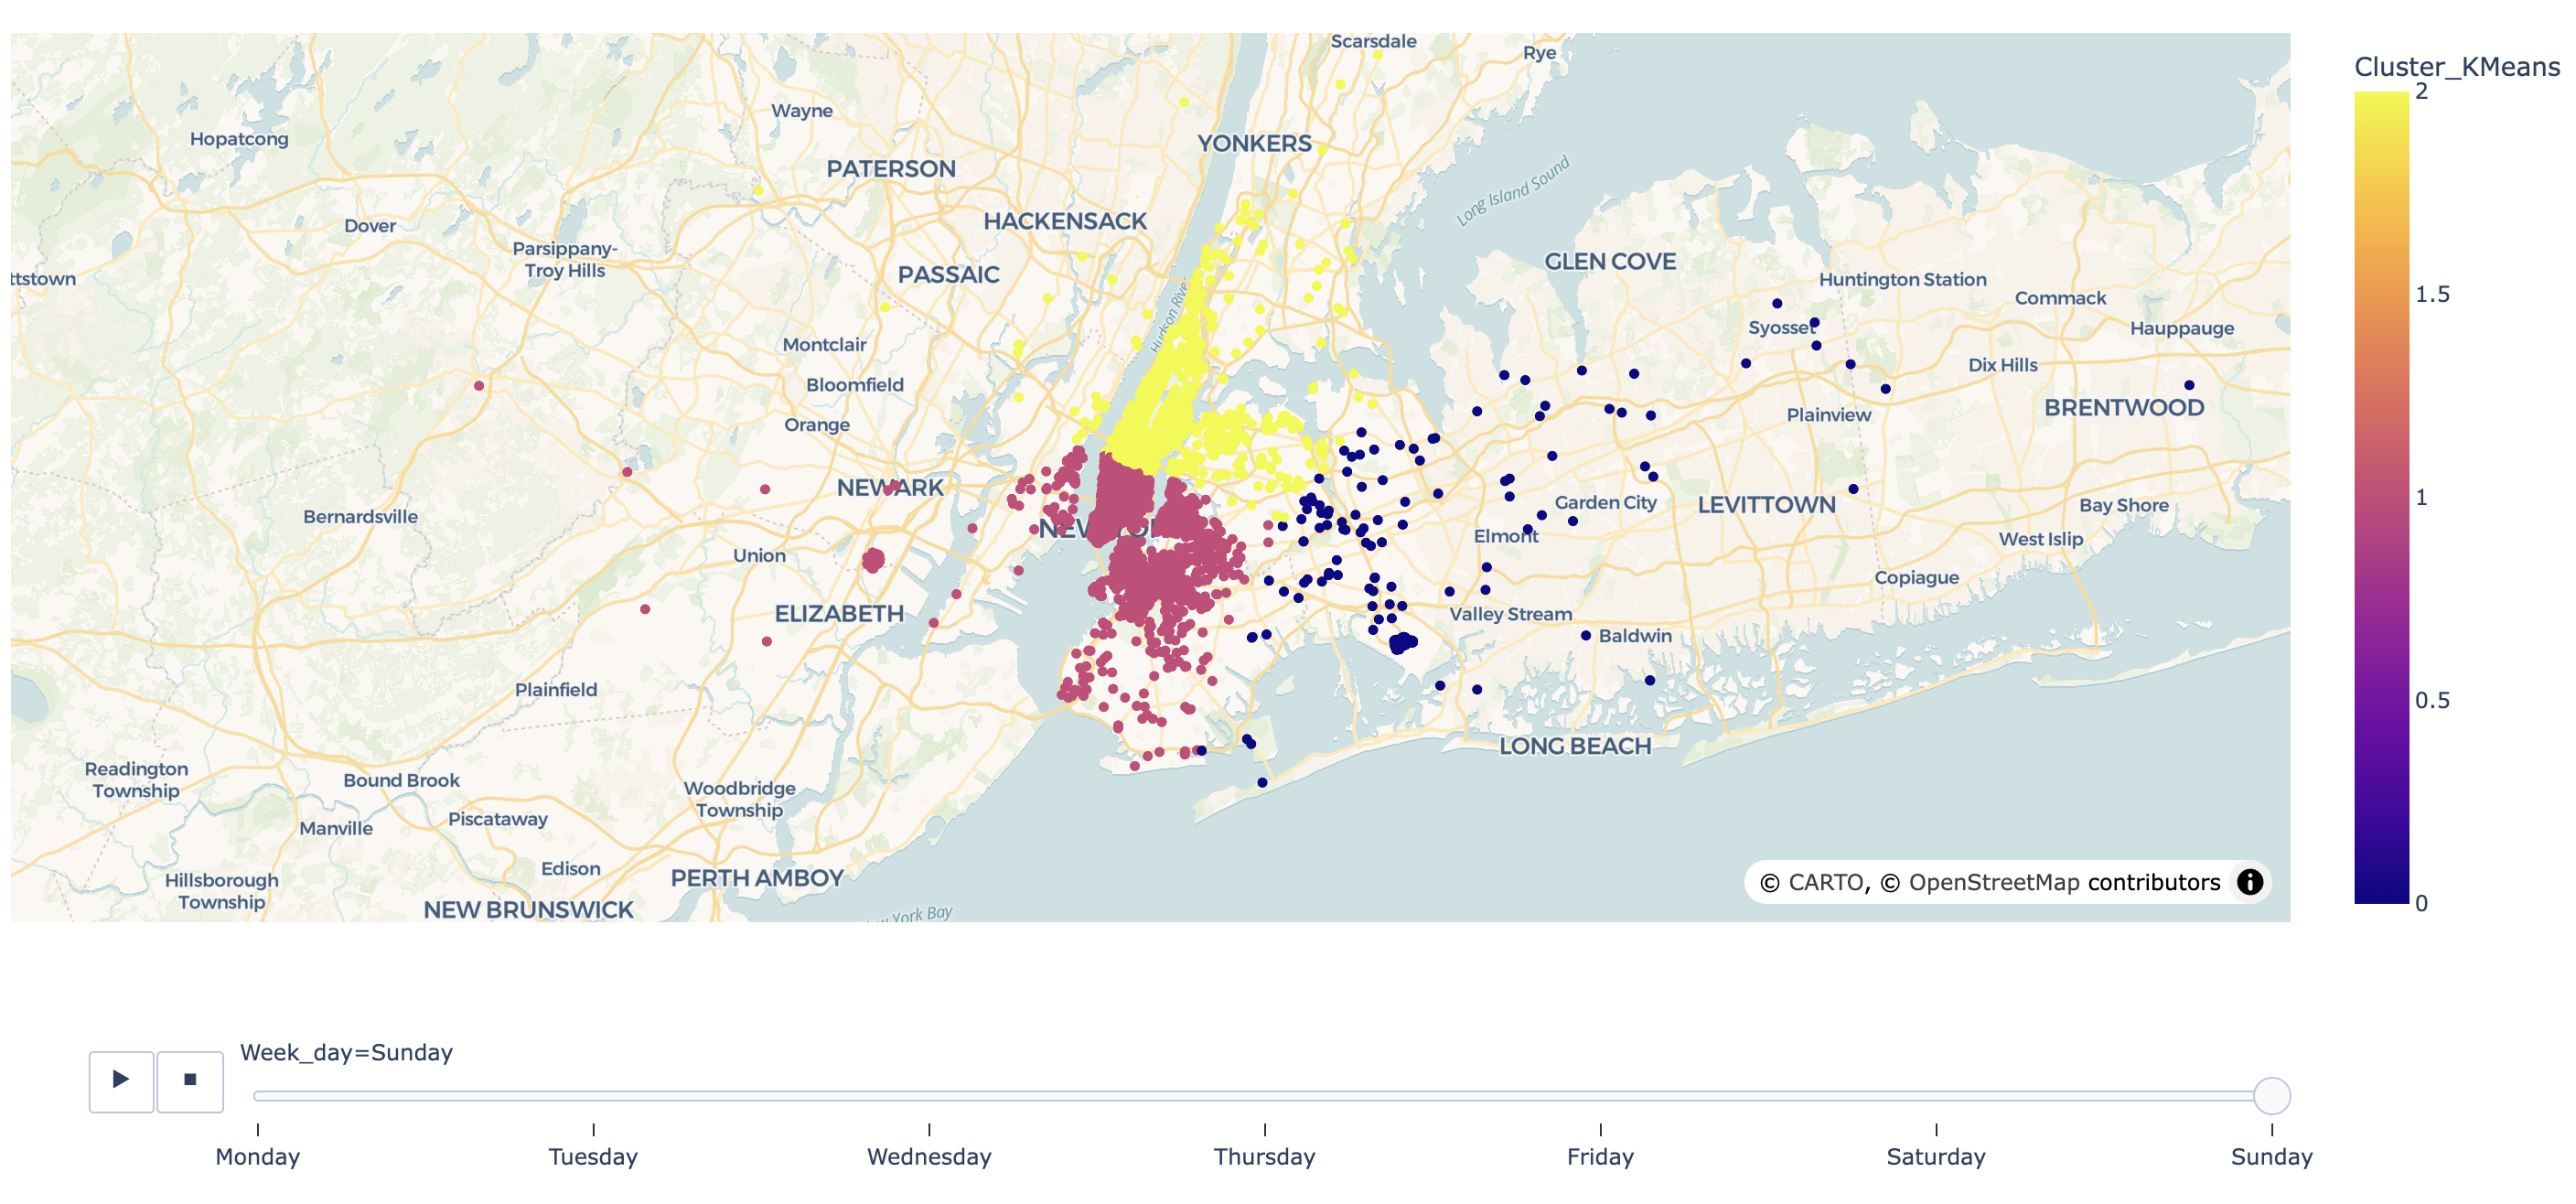

K-Means identified three major operational areas in New York City. The weekday animation reveals only minor changes in cluster density, while the overall cluster structure remains stable throughout the week. The persistence of these dominant pickup zones suggests that demand is driven primarily by geographic factors rather than by the specific day of the week.

## DBSCAN

In [42]:
dbscan = DBSCAN(eps=0.08, min_samples=50)

uber_sample['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

uber_sample['Cluster_DBSCAN'].value_counts().head()


Cluster_DBSCAN
 0    37500
-1     4359
 2     2881
 5     2316
 1     1085
Name: count, dtype: int64

## DBSCAN Hot Zones Map

In [45]:
file_path = "../data/image/Cluster_dbscan.html"

fig = px.scatter_map(
    uber_sample[uber_sample['Cluster_DBSCAN'] != -1].sort_values('Week_day'),
    lat='Lat',
    lon='Lon',
    color='Cluster_DBSCAN',
    animation_frame='Week_day',
    zoom=9,
    height=700
)

fig.write_html(file_path)

webbrowser.open(f"file://{Path(file_path).resolve()}")


True

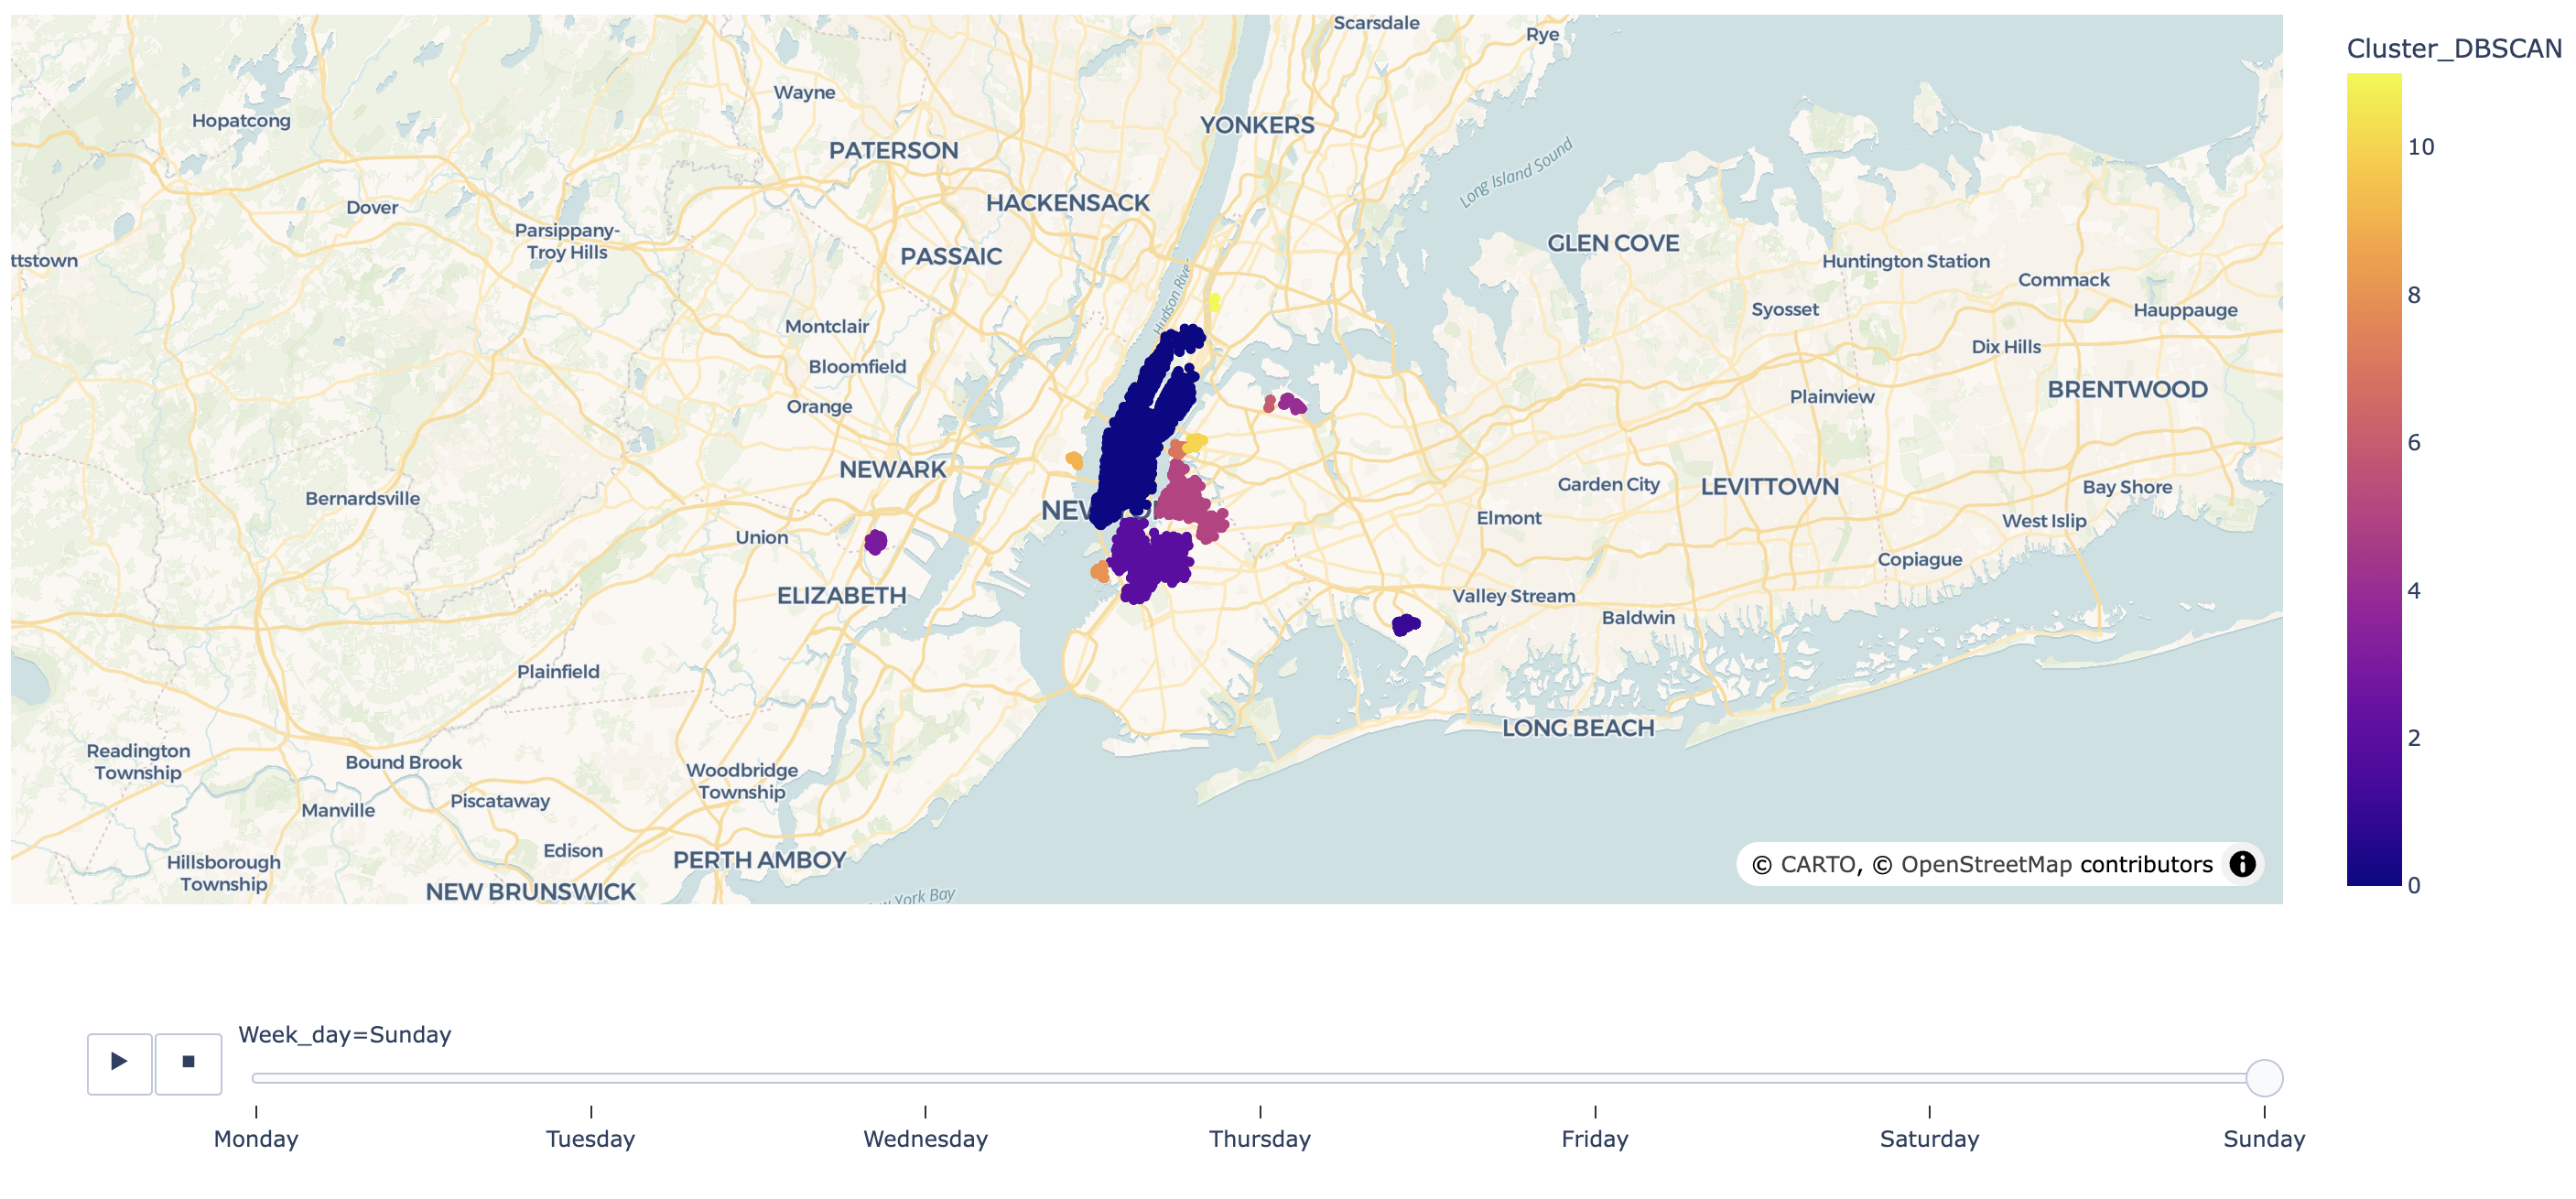

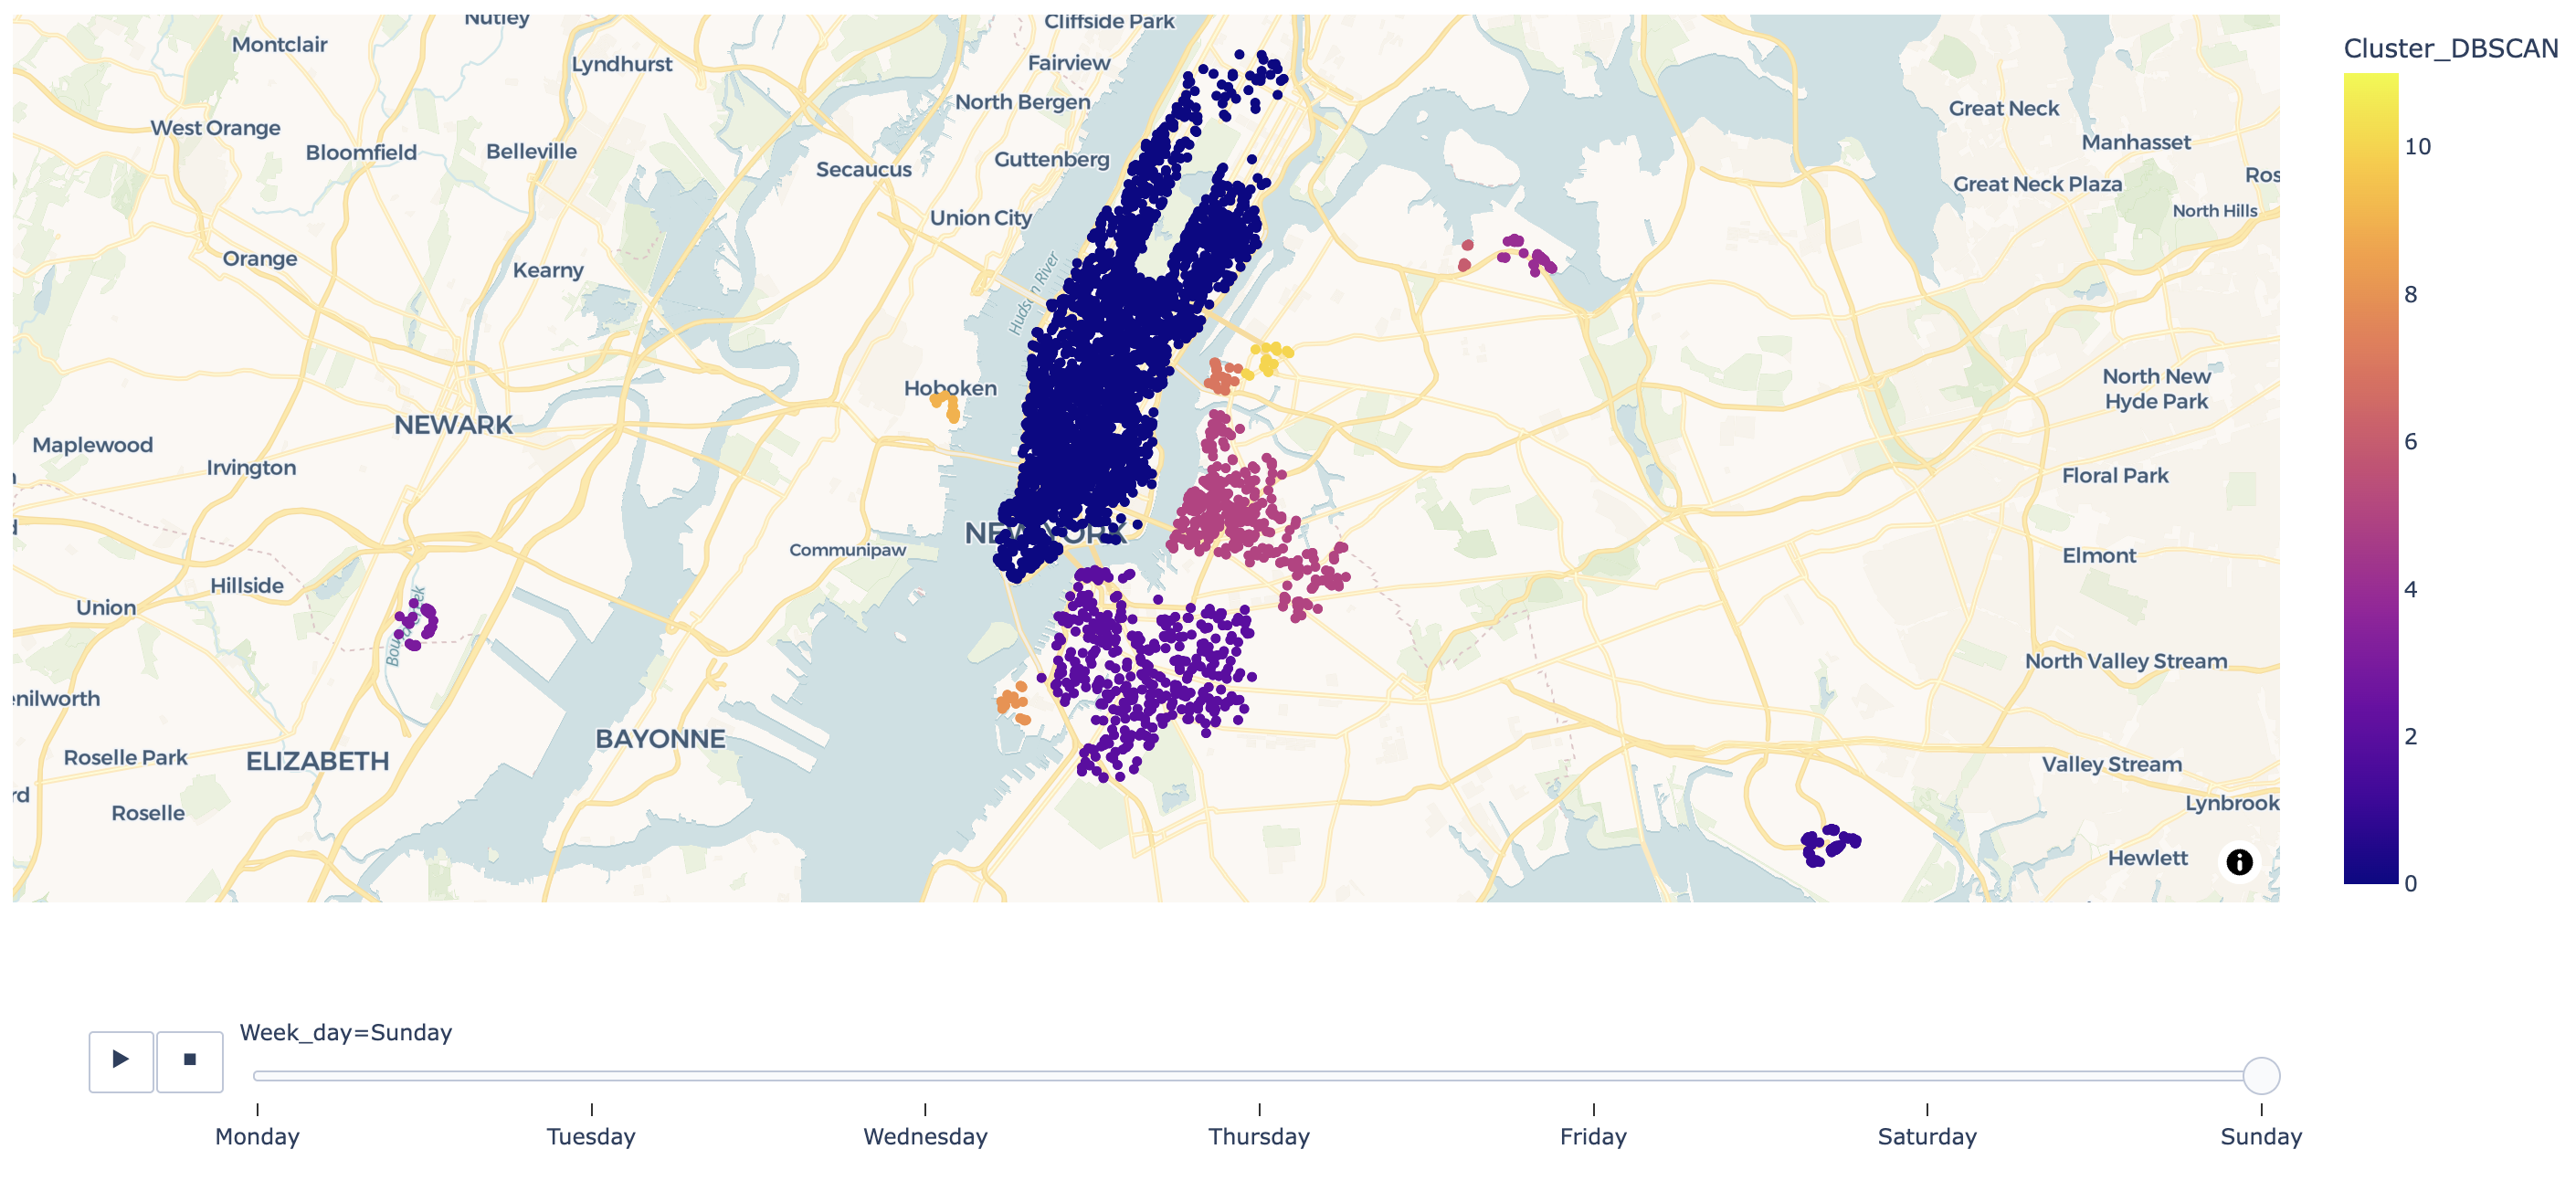

Applying DBSCAN to geographical coordinates (latitude and longitude) reveals several high-density zones that correspond to the main Uber demand hubs in New York. Although cluster density varies slightly across weekdays, the overall cluster structure remains remarkably stable throughout the week. This consistency indicates that geographic location is the primary driver of pickup demand, while the day of the week has a relatively limited impact on the spatial distribution of rides.

## Comparison

The combined interpretation of the Elbow and Silhouette methods suggested that **K = 3** offered the best compromise between cluster compactness and interpretability. While the silhouette score slightly favored a smaller number of clusters, the Elbow method revealed diminishing returns beyond three clusters, and the resulting segmentation provided a more meaningful representation of New York City's main pickup zones.

However, despite this reasonable choice of K, K-Means presents important limitations in a geographic context. Because every data point must be assigned to a cluster, the algorithm is forced to include isolated and low-density pickups, stretching cluster boundaries and creating artificial partitions across the map.

In contrast, DBSCAN incorporates a built-in notion of noise and naturally excludes isolated observations. This allows the algorithm to focus on dense demand areas and to identify clusters that better reflect the actual spatial structure of New York City. As a result, DBSCAN produces more realistic hot zones that align with established neighborhoods and major demand hubs, providing a more intuitive representation of Uber pickup activity.


## Conclusion

The clustering analysis identified several recurring Uber pickup hot zones across New York City. The largest concentration of pickups is located in Manhattan, which appears as the dominant demand area throughout the week. Additional clusters are present in Brooklyn and Queens, while a few smaller clusters can be observed in more peripheral locations.

The weekday analysis shows only minor variations in cluster density from Monday to Sunday. Overall, the location of the hot zones remains stable, suggesting that pickup demand is driven more by geography than by the day of the week.

From a business perspective, these results indicate that drivers looking to maximize their chances of finding passengers should mainly position themselves in Manhattan, where demand is consistently the highest. Brooklyn and Queens also represent important pickup areas and may provide additional opportunities during periods of high demand.